# Whitout balanced data 

In [2]:
import pandas as pd
import polars as pl


In [3]:
df = pd.read_csv("CKD_Dataset.csv")
df.head()

,Age,Gender,BMI,SystolicBP,HeartRate,SerumCreatinine,BloodUrea,eGFR,Albumin,Protein_Urine,...,Triglycerides,BloodSugar,HbA1c,ProteinInDiet,SmokerStatus,PhysicalActivity,MedicationUse,PastKidneyStones,Microalbuminuria,CKD_Label
0,55.9,Male,29.3,146.0,81.0,0.50,10.0,80.6,0.0,0.6,...,80.8,87.7,7.09,62.5,Former,Medium,1,0,7.2,0
1,85.0,Male,25.9,125.0,86.0,3.34,64.6,29.0,3.1,2.4,...,176.2,108.7,8.38,39.6,Never,Medium,1,0,62.0,1
2,72.0,Male,27.1,117.0,91.0,3.29,67.0,30.9,4.0,3.5,...,124.9,144.9,7.47,49.8,Former,Medium,0,1,10.7,1
3,25.0,Female,23.3,156.0,73.0,2.22,12.6,90.2,0.0,0.9,...,126.3,100.4,4.80,78.5,Never,High,0,0,12.2,0
4,82.2,Male,29.4,145.0,112.0,2.06,62.1,19.8,2.7,3.2,...,110.5,121.3,5.50,43.9,Former,Low,1,0,91.1,1


In [4]:
df['CKD_Label'].value_counts()

CKD_Label
0    500
1    500
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   float64
 1   Gender               1000 non-null   object 
 2   BMI                  1000 non-null   float64
 3   SystolicBP           1000 non-null   float64
 4   HeartRate            1000 non-null   float64
 5   SerumCreatinine      1000 non-null   float64
 6   BloodUrea            1000 non-null   float64
 7   eGFR                 1000 non-null   float64
 8   Albumin              1000 non-null   float64
 9   Protein_Urine        1000 non-null   float64
 10  Sugar_Urine          1000 non-null   float64
 11  PusCells             1000 non-null   object 
 12  Sodium               1000 non-null   float64
 13  Potassium            1000 non-null   float64
 14  Calcium              1000 non-null   float64
 15  Hemoglobin           1000 non-null   fl

## filing missing valuees

In [6]:
cat_col , num_col = df.select_dtypes('object').columns, df.select_dtypes(['int64', 'float64']).columns

df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])
df[num_col] = df[num_col].fillna(df[num_col].median())

In [7]:
df[cat_col]

,Gender,PusCells,Appetite,SmokerStatus,PhysicalActivity
0,Male,Normal,Good,Former,Medium
1,Male,Abnormal,Poor,Never,Medium
2,Male,Abnormal,Poor,Former,Medium
3,Female,Normal,Good,Never,High
4,Male,Abnormal,Good,Former,Low
...,...,...,...,...,...
995,Female,Abnormal,Poor,Never,Medium
996,Male,Abnormal,Poor,Never,Medium
997,Male,Normal,Poor,Former,Medium
998,Male,Normal,Poor,Former,High


In [8]:
# df.isnull().sum()

In [9]:
for cat in cat_col:
    print("*"*50)
    print(df[cat].value_counts())
    print('\n\n')
 


**************************************************
Gender
Female    502
Male      498
Name: count, dtype: int64



**************************************************
PusCells
Normal      583
Abnormal    417
Name: count, dtype: int64



**************************************************
Appetite
Good    586
Poor    414
Name: count, dtype: int64



**************************************************
SmokerStatus
Never      490
Former     310
Current    200
Name: count, dtype: int64



**************************************************
PhysicalActivity
Low       411
Medium    383
High      206
Name: count, dtype: int64





In [10]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

encode_df = df.copy()
for cat in cat_col:
    encode_df[cat] = encode.fit_transform(encode_df[cat])



In [11]:
encode_df[cat_col]

,Gender,PusCells,Appetite,SmokerStatus,PhysicalActivity
0,1,1,0,1,2
1,1,0,1,2,2
2,1,0,1,1,2
3,0,1,0,2,0
4,1,0,0,1,1
...,...,...,...,...,...
995,0,0,1,2,2
996,1,0,1,2,2
997,1,1,1,1,2
998,1,1,1,1,0


In [12]:
X, y = encode_df.drop(['CKD_Label'], axis=1), encode_df['CKD_Label']

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
         

    "dt":DecisionTreeClassifier(),

    'gnb':GaussianNB( ),

    "SVM": SVC(
        kernel="rbf",
        C=0.5,                 # Lower C = more regularization (prevents overfitting)
        gamma="scale",         # Uses 1 / (n_features * X.var())
        class_weight="balanced",
        probability=True,      # Keep True only if you need ROC-AUC or soft voting
        cache_size=500,        # Uses more RAM to speed up training
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
         
    ),
    
    
    "KNN": KNeighborsClassifier( ),


    # "grdi":GradientBoostingClassifier(learning_rate=0.001, n_estimators=100, min_samples_split=0.2),


    "XGBoost": XGBClassifier(
        n_estimators=100 
    )
}

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [16]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9253

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8521
False Positive Rate (FPR): 0.1772

Accuracy  : 0.8367
Precision : 0.8121
Recall    : 0.8521
F1-Score  : 0.8316
ROC-AUC   : 0.8374

Confusion Matrix:
[[130  28]
 [ 21 

In [17]:
X = encode_df.drop(['CKD_Label'], axis=1).to_numpy()
y =  df['CKD_Label'].to_numpy()

In [18]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "CKD_results"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model

model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Validation Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.3159, Val Loss: 0.3320
Epoch 20, Train Loss: 0.3138, Val Loss: 0.3385
Early stopping at epoch: 30

Threshold Tuning:
Threshold 0.30: Accuracy 0.9400
Threshold 0.35: Accuracy 0.9467
Threshold 0.40: Accuracy 0.9467
Threshold 0.45: Accuracy 0.9533
Threshold 0.50: Accuracy 0.9533
Threshold 0.55: Accuracy 0.9533
Threshold 0.60: Accuracy 0.9467
Threshold 0.65: Accuracy 0.9467
Threshold 0.70: Accuracy 0.9400
Threshold 0.75: Accuracy 0.9133

Best Threshold: 0.45

Final Results:
Accuracy: 0.9533333333333334

Confusion Matrix:
[[75  2]
 [ 5 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96        77
         1.0       0.97      0.93      0.95        73

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

True Positive Rate (TPR):  0.9315
False Positive Rate (FPR): 0.0260

ROC-AUC Score:

In [19]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "CKD_results_0"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Test Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.1840, Val Loss: 0.4484
Early stopping at epoch: 17

Threshold Tuning:
Threshold 0.30: Accuracy 0.8933
Threshold 0.35: Accuracy 0.8867
Threshold 0.40: Accuracy 0.8867
Threshold 0.45: Accuracy 0.8800
Threshold 0.50: Accuracy 0.8733
Threshold 0.55: Accuracy 0.8667
Threshold 0.60: Accuracy 0.8733
Threshold 0.65: Accuracy 0.8933
Threshold 0.70: Accuracy 0.9067
Threshold 0.75: Accuracy 0.8933

Best Threshold: 0.70

Final Results:
Accuracy: 0.9066666666666666

Confusion Matrix:
[[73  4]
 [10 63]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91        77
         1.0       0.94      0.86      0.90        73

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150


ROC-AUC Score:
0.9261697206902687
True Positive Rate (TPR):  0.8630
False Positive Rate (FPR): 0.0519
Precision: 0.9403
Recall:  

## sdfc


In [20]:
X = encode_df.drop('CKD_Label', axis=1)
y = encode_df['CKD_Label']

In [21]:
from sklearn.feature_selection import SelectKBest, f_classif

sdfs = SelectKBest(score_func=f_classif, k=10)
X_sdfs = sdfs.fit_transform(X, y)

selected_sdfs = X.columns[sdfs.get_support()]
print("SDFS Selected:", selected_sdfs)

SDFS Selected: Index(['SerumCreatinine', 'BloodUrea', 'eGFR', 'Albumin', 'Protein_Urine',
       'Hemoglobin', 'RBC_Count', 'FatigueLevel', 'UrineOutput_mL',
       'PhosphateLevel'],
      dtype='object')


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_sdfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [23]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9107

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8310
False Positive Rate (FPR): 0.1709

Accuracy  : 0.8300
Precision : 0.8138
Recall    : 0.8310
F1-Score  : 0.8223
ROC-AUC   : 0.8300

Confusion Matrix:
[[131  27]
 [ 24 

In [24]:
X = encode_df.drop(['CKD_Label'], axis=1).to_numpy()
y =  df['CKD_Label'].to_numpy()

Epoch 10, Train Loss: 0.1826, Val Loss: 0.5156
Early stopping at epoch: 17

Threshold Tuning:
Threshold 0.30: Accuracy 0.9000
Threshold 0.35: Accuracy 0.9067
Threshold 0.40: Accuracy 0.9133
Threshold 0.45: Accuracy 0.9133
Threshold 0.50: Accuracy 0.9133
Threshold 0.55: Accuracy 0.9067
Threshold 0.60: Accuracy 0.9067
Threshold 0.65: Accuracy 0.9000
Threshold 0.70: Accuracy 0.9000
Threshold 0.75: Accuracy 0.8933

Best Threshold: 0.40

Final Results:
Accuracy: 0.9133333333333333

Confusion Matrix:
[[74  3]
 [10 63]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92        77
         1.0       0.95      0.86      0.91        73

    accuracy                           0.91       150
   macro avg       0.92      0.91      0.91       150
weighted avg       0.92      0.91      0.91       150


ROC-AUC Score:
0.9363102650773883
True Positive Rate (TPR):  0.8630
False Positive Rate (FPR): 0.0390
Precision: 0.9545
Recall:  

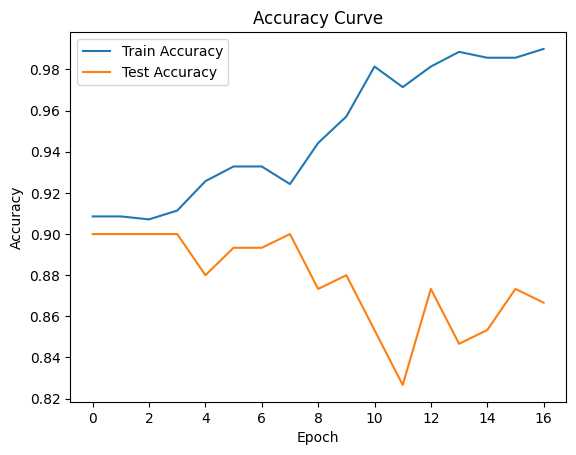

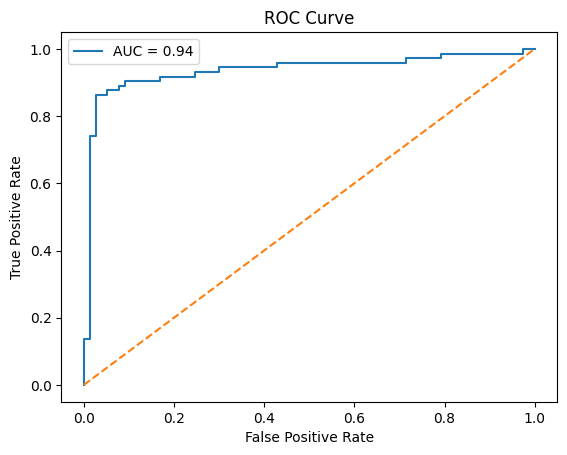

In [25]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "SDFS_results_0_CKD"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## cfs

In [26]:
X = encode_df.drop('CKD_Label', axis=1)
y = encode_df['CKD_Label']

In [27]:
import numpy as np

corr = X.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.85)]

X_cfs = X.drop(columns=drop_cols)

print("Dropped:", drop_cols)
print("CFS Remaining:", X_cfs.columns)

Dropped: []
CFS Remaining: Index(['Age', 'Gender', 'BMI', 'SystolicBP', 'HeartRate', 'SerumCreatinine',
       'BloodUrea', 'eGFR', 'Albumin', 'Protein_Urine', 'Sugar_Urine',
       'PusCells', 'Sodium', 'Potassium', 'Calcium', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Appetite', 'Edema', 'FatigueLevel', 'FluidIntake_L',
       'UrineOutput_mL', 'DialysisHistory', 'DiabetesHistory',
       'HypertensionHistory', 'PhosphateLevel', 'UricAcid', 'Bicarbonate',
       'Chloride', 'Magnesium', 'Cholesterol_Total', 'Triglycerides',
       'BloodSugar', 'HbA1c', 'ProteinInDiet', 'SmokerStatus',
       'PhysicalActivity', 'MedicationUse', 'PastKidneyStones',
       'Microalbuminuria'],
      dtype='object')


In [28]:
X_cfs.head(
)

,Age,Gender,BMI,SystolicBP,HeartRate,SerumCreatinine,BloodUrea,eGFR,Albumin,Protein_Urine,...,Cholesterol_Total,Triglycerides,BloodSugar,HbA1c,ProteinInDiet,SmokerStatus,PhysicalActivity,MedicationUse,PastKidneyStones,Microalbuminuria
0,55.9,1,29.3,146.0,81.0,0.50,10.0,80.6,0.0,0.6,...,235.2,80.8,87.7,7.09,62.5,1,2,1,0,7.2
1,85.0,1,25.9,125.0,86.0,3.34,64.6,29.0,3.1,2.4,...,202.8,176.2,108.7,8.38,39.6,2,2,1,0,62.0
2,72.0,1,27.1,117.0,91.0,3.29,67.0,30.9,4.0,3.5,...,253.4,124.9,144.9,7.47,49.8,1,2,0,1,10.7
3,25.0,0,23.3,156.0,73.0,2.22,12.6,90.2,0.0,0.9,...,157.8,126.3,100.4,4.80,78.5,2,0,0,0,12.2
4,82.2,1,29.4,145.0,112.0,2.06,62.1,19.8,2.7,3.2,...,239.5,110.5,121.3,5.50,43.9,1,1,1,0,91.1


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_cfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [30]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9253

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8310
False Positive Rate (FPR): 0.1456

Accuracy  : 0.8433
Precision : 0.8369
Recall    : 0.8310
F1-Score  : 0.8339
ROC-AUC   : 0.8427

Confusion Matrix:
[[135  23]
 [ 24 

## bfe

In [31]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

bfe = RFE(model, n_features_to_select=30)
bfe.fit(X, y)

selected_bfe = X.columns[bfe.support_]
print("BFE Selected:", selected_bfe)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://sciki

BFE Selected: Index(['Age', 'Gender', 'BMI', 'SerumCreatinine', 'eGFR', 'Albumin',
       'Protein_Urine', 'Sugar_Urine', 'PusCells', 'Potassium', 'Calcium',
       'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Appetite', 'Edema',
       'FatigueLevel', 'FluidIntake_L', 'DialysisHistory', 'DiabetesHistory',
       'HypertensionHistory', 'PhosphateLevel', 'UricAcid', 'Chloride',
       'Magnesium', 'HbA1c', 'SmokerStatus', 'PhysicalActivity',
       'MedicationUse', 'PastKidneyStones'],
      dtype='object')


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://sciki

In [32]:
selected_bfe.values


array(['Age', 'Gender', 'BMI', 'SerumCreatinine', 'eGFR', 'Albumin',
       'Protein_Urine', 'Sugar_Urine', 'PusCells', 'Potassium', 'Calcium',
       'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Appetite', 'Edema',
       'FatigueLevel', 'FluidIntake_L', 'DialysisHistory',
       'DiabetesHistory', 'HypertensionHistory', 'PhosphateLevel',
       'UricAcid', 'Chloride', 'Magnesium', 'HbA1c', 'SmokerStatus',
       'PhysicalActivity', 'MedicationUse', 'PastKidneyStones'],
      dtype=object)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_bfe], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [34]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9290

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8310
False Positive Rate (FPR): 0.1709

Accuracy  : 0.8300
Precision : 0.8138
Recall    : 0.8310
F1-Score  : 0.8223
ROC-AUC   : 0.8300

Confusion Matrix:
[[131  27]
 [ 24 

pso

In [35]:
# from pyswarm import pso
# from sklearn.model_selection import cross_val_score
# from sklearn.ensemble import RandomForestClassifier

# def fitness_function(mask):
#     mask = mask > 0.5
#     if sum(mask) == 0:
#         return 1
    
#     X_selected = X.iloc[:, mask]
#     model = RandomForestClassifier()
    
#     score = cross_val_score(model, X_selected, y, cv=3).mean()
    
#     return 1 - score  # minimize

# lb = [0]*X.shape[1]
# ub = [1]*X.shape[1]

# best_mask, _ = pso(fitness_function, lb, ub)

# selected_pso = X.columns[best_mask > 0.5]
# print("PSO Selected:", selected_pso)

## ga

In [36]:
from sklearn_genetic import GAFeatureSelectionCV
from sklearn.ensemble import RandomForestClassifier

ga = GAFeatureSelectionCV(
    estimator=RandomForestClassifier(),
    cv=3,
    scoring="accuracy",
    population_size=10,
    generations=10,
    n_jobs=-1
)

ga.fit(X, y)

selected_ga = X.columns[ga.support_]
print("GA Selected:", selected_ga)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	10    	0.912882	0.00121822 	0.91398    	0.909988   
1  	20    	0.91398 	0.000632141	0.914981   	0.912982   
2  	20    	0.91408 	0.0003003  	0.914981   	0.91398    
3  	20    	0.91398 	0.000446992	0.914981   	0.912982   
4  	20    	0.91398 	1.11022e-16	0.91398    	0.91398    
5  	20    	0.91398 	1.11022e-16	0.91398    	0.91398    
6  	20    	0.91378 	0.000399202	0.91398    	0.912982   
7  	20    	0.91398 	1.11022e-16	0.91398    	0.91398    
8  	20    	0.91398 	0.000447661	0.914981   	0.912979   
9  	20    	0.91408 	0.000538444	0.914981   	0.912982   
10 	20    	0.91418 	0.000600002	0.914981   	0.912982   
GA Selected: Index(['Age', 'HeartRate', 'SerumCreatinine', 'PusCells', 'RBC_Count',
       'Appetite', 'FatigueLevel', 'FluidIntake_L', 'PhosphateLevel',
       'UricAcid', 'Bicarbonate', 'Magnesium', 'Cholesterol_Total',
       'BloodSugar', 'SmokerStatus', 'PhysicalActivity', 'Microalbuminuria'],
      dtype='object')


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ga], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [38]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0759

Accuracy  : 0.9233
Precision : 0.9161
Recall    : 0.9225
F1-Score  : 0.9193
ROC-AUC   : 0.9163

Confusion Matrix:
[[146  12]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8239
False Positive Rate (FPR): 0.2215

Accuracy  : 0.8000
Precision : 0.7697
Recall    : 0.8239
F1-Score  : 0.7959
ROC-AUC   : 0.8012

Confusion Matrix:
[[123  35]
 [ 25 

##  ssa

In [39]:
import random

def salp_swarm(X, y, iterations=10):
    best_features = list(X.columns)
    best_score = 0
    
    for _ in range(iterations):
        selected = random.sample(list(X.columns), k=30)
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_ssa = salp_swarm(X, y)
print("SSA Selected:", selected_ssa)

SSA Selected: ['UrineOutput_mL', 'PhysicalActivity', 'Age', 'SystolicBP', 'RBC_Count', 'BMI', 'Bicarbonate', 'Calcium', 'FluidIntake_L', 'WBC_Count', 'ProteinInDiet', 'DiabetesHistory', 'Protein_Urine', 'eGFR', 'Magnesium', 'Hemoglobin', 'Microalbuminuria', 'HypertensionHistory', 'Chloride', 'FatigueLevel', 'Potassium', 'HbA1c', 'BloodSugar', 'PastKidneyStones', 'Gender', 'HeartRate', 'UricAcid', 'Cholesterol_Total', 'Sugar_Urine', 'Albumin']


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ssa], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [41]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9253

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8099
False Positive Rate (FPR): 0.1456

Accuracy  : 0.8333
Precision : 0.8333
Recall    : 0.8099
F1-Score  : 0.8214
ROC-AUC   : 0.8321

Confusion Matrix:
[[135  23]
 [ 27 

## rsfs

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importance = rf.feature_importances_

selected_rsfs = X.columns[importance > np.mean(importance)]
print("RSFS Selected:", selected_rsfs)

RSFS Selected: Index(['SerumCreatinine', 'BloodUrea', 'eGFR', 'Albumin', 'Hemoglobin',
       'RBC_Count', 'FatigueLevel', 'FluidIntake_L', 'UrineOutput_mL',
       'PhosphateLevel', 'ProteinInDiet'],
      dtype='object')


In [43]:
chart = pd.DataFrame({
    'Feature': X.columns,
    'importance': importance
})

# Keep features above mean importance
selected_features = chart[chart['importance'] > chart['importance'].mean()]

print(selected_features)

            Feature  importance
5   SerumCreatinine    0.025871
6         BloodUrea    0.058007
7              eGFR    0.137175
8           Albumin    0.072248
15       Hemoglobin    0.063763
16        RBC_Count    0.079844
20     FatigueLevel    0.058782
21    FluidIntake_L    0.036663
22   UrineOutput_mL    0.118844
26   PhosphateLevel    0.051484
35    ProteinInDiet    0.028428


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_rsfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [45]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9082

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8380
False Positive Rate (FPR): 0.1709

Accuracy  : 0.8333
Precision : 0.8151
Recall    : 0.8380
F1-Score  : 0.8264
ROC-AUC   : 0.8336

Confusion Matrix:
[[131  27]
 [ 23 

In [46]:
X = encode_df[selected_rsfs].to_numpy()
y =  df['CKD_Label'].to_numpy()

Epoch 10, Train Loss: 0.2853, Val Loss: 0.3871
Early stopping at epoch: 18

Threshold Tuning:
Threshold 0.30: Accuracy 0.9467
Threshold 0.35: Accuracy 0.9467
Threshold 0.40: Accuracy 0.9533
Threshold 0.45: Accuracy 0.9533
Threshold 0.50: Accuracy 0.9467
Threshold 0.55: Accuracy 0.9467
Threshold 0.60: Accuracy 0.9400
Threshold 0.65: Accuracy 0.9400
Threshold 0.70: Accuracy 0.9267
Threshold 0.75: Accuracy 0.9200

Best Threshold: 0.40

Final Results:
Accuracy: 0.9533333333333334

Confusion Matrix:
[[75  2]
 [ 5 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96        77
         1.0       0.97      0.93      0.95        73

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


ROC-AUC Score:
0.9530332681017613
True Positive Rate (TPR):  0.9315
False Positive Rate (FPR): 0.0260
Precision: 0.9714
Recall:  

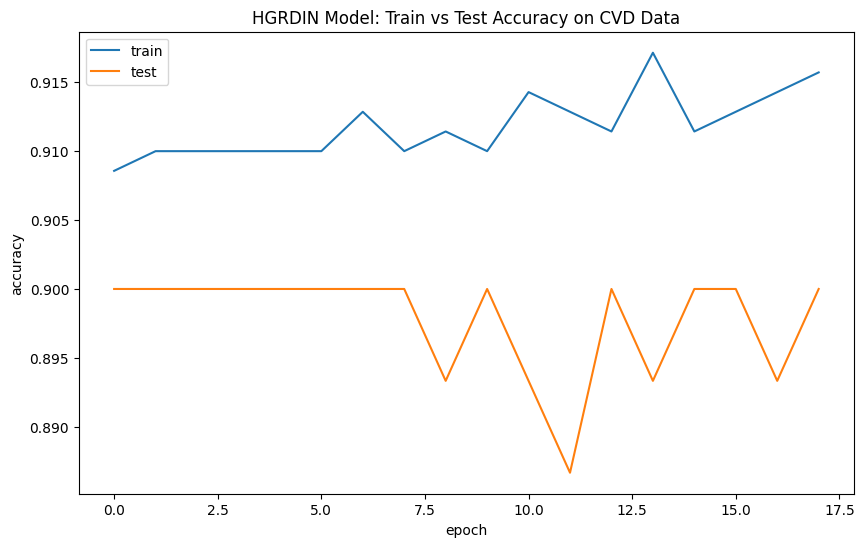

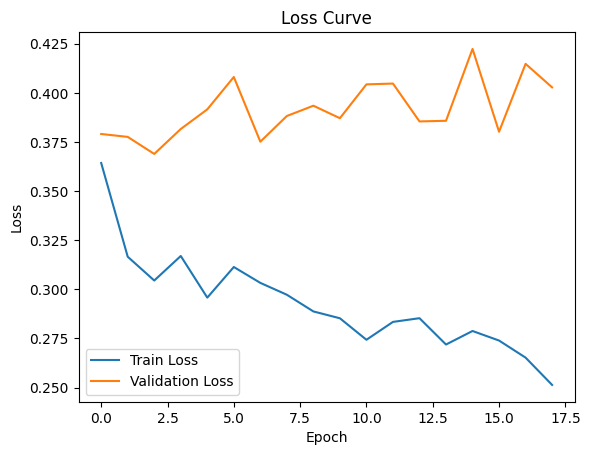

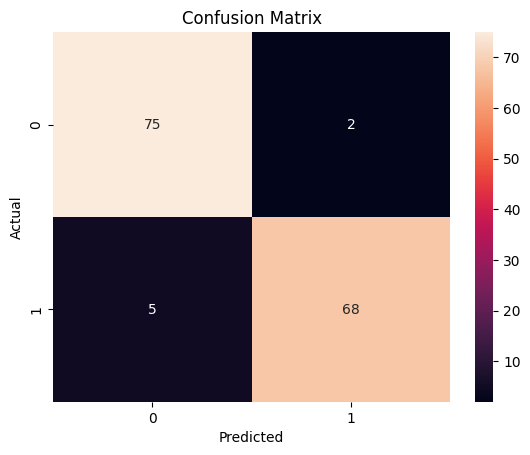

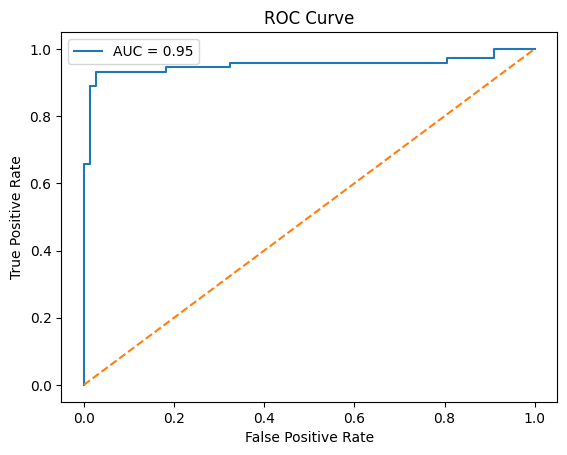

In [47]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "RSFS_results_0_ckd"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:

# X = encode_df[selected_rsfs].values
# y =  y.values

# X = encode_df[selected_rsfs].to_numpy()
# y =  y.to_numpy()

# =========================
# 3. Train / Val / Test Split
# =========================
 
X_train, X_temp , y_train, y_temp = train_test_split( X, y, test_size=0.3, random_state=42)
 

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
# ========================================================
# 13. Visualization: Train vs Test Accuracy (CVD Data)
# ========================================================

plt.figure(figsize=(10, 6))

# Plotting the lists collected during the training loop
plt.plot(train_acc_list, label='train')
plt.plot(val_acc_list, label='test') # Using val_acc_list as the 'test' proxy during training

# Labeling according to your provided chart style
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('HGRDIN Model: Train vs Test Accuracy on CVD Data')
plt.legend(loc='upper left')

# Optional: Match the y-axis starting point of your image (0.45 or 0.5)
# plt.ylim(bottom=0.45, top=1.0) 

plt.savefig(os.path.join(results_dir, "hgrdin_accuracy_comparison.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## apdfs

In [48]:
X = encode_df.drop('CKD_Label', axis=1)
y= encode_df['CKD_Label']

In [49]:
import numpy as np

def apdfs(X, y, iterations=20):
    best_features = None
    best_score = 0
    
    for _ in range(iterations):
        prob = np.random.rand(X.shape[1])
        mask = prob > 0.5
        
        if sum(mask) == 0:
            continue
        
        selected = X.columns[mask]
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_apdfs = apdfs(X, y)
print("APDFS Selected:", selected_apdfs)

APDFS Selected: Index(['Age', 'SerumCreatinine', 'Albumin', 'Sugar_Urine', 'PusCells',
       'Potassium', 'Hemoglobin', 'RBC_Count', 'Appetite', 'Edema',
       'FluidIntake_L', 'DialysisHistory', 'HypertensionHistory', 'UricAcid',
       'Bicarbonate', 'Triglycerides', 'BloodSugar', 'SmokerStatus',
       'PhysicalActivity'],
      dtype='object')


In [59]:
import matplotlib.pyplot as plt
import os

# Create results folder
results_dir = "results_roc_CKD"
os.makedirs(results_dir, exist_ok=True)

# Loop through each model to create individual plots
for model_name, metrics in results.items():
    # 1. Create a NEW figure for every model
    plt.figure(figsize=(8, 6))
    
    # 2. Plot the specific model line
    plt.plot(
        metrics['fpr'], 
        metrics['tpr'], 
        color='darkorange',
        lw=2, 
        label=f"{model_name} (AUC = {metrics['AUC']:.4f})"
    )

    # 3. Add the baseline "Random Guess" line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.50)')

    # 4. Formatting (Individual for this model)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # 5. Save using the model name in the filename
    # Sanitize model name to avoid filename issues (replace spaces with underscores)
    clean_name = model_name.replace(" ", "_")
    save_path = os.path.join(results_dir, f"roc_{clean_name}.png")
    plt.savefig(save_path)
    
    # 6. Close the plot to free up memory before the next loop
    # plt.show() 
    plt.close()

print(f"All individual charts have been saved in: {results_dir}")

All individual charts have been saved in: results_roc_CKD


In [50]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

def calculate_feature_divergence(df, target_col):
    """
    Measures the 'Goodness' of features using Symmetrical KL Divergence.
    High score = High class separability.
    """
    divergence_scores = {}
    
    # Separate the classes
    class_labels = df[target_col].unique()
    group1 = df[df[target_col] == class_labels[0]]
    group2 = df[df[target_col] == class_labels[1]]
    
    for col in df.columns:
        if col == target_col: continue
        
        # Calculate probability distributions (binned for continuous data)
        # Using 10 bins to normalize comparison between different scales
        p_data = group1[col]
        q_data = group2[col]
        
        # Create a common histogram range
        all_min, all_max = df[col].min(), df[col].max()
        bins = np.linspace(all_min, all_max, 11)
        
        p_hist, _ = np.histogram(p_data, bins=bins, density=True)
        q_hist, _ = np.histogram(q_data, bins=bins, density=True)
        
        # Add epsilon to avoid division by zero (Laplace smoothing)
        p_hist += 1e-10
        q_hist += 1e-10
        
        # Symmetrical KL Divergence: D(P||Q) + D(Q||P)
        div = (entropy(p_hist, q_hist) + entropy(q_hist, p_hist)) / 2
        divergence_scores[col] = div

    # Return sorted results
    return pd.Series(divergence_scores).sort_values(ascending=False)

# --- Usage with CKD Data ---
# Pre-requisite: X and y must be numeric (use LabelEncoder for categories)
results = calculate_feature_divergence(encode_df, 'CKD_Label')
print(results)

UrineOutput_mL         1.746350
eGFR                   1.744190
PhosphateLevel         1.535633
Hemoglobin             1.492689
Albumin                1.491819
FatigueLevel           1.469815
RBC_Count              1.385516
Protein_Urine          1.338852
BloodUrea              1.324520
FluidIntake_L          1.276068
SerumCreatinine        1.242807
ProteinInDiet          1.086062
Sugar_Urine            1.022428
Bicarbonate            1.021085
UricAcid               0.950827
SystolicBP             0.935108
Microalbuminuria       0.932013
Sodium                 0.876127
Calcium                0.852443
Potassium              0.764353
Edema                  0.752208
Chloride               0.734032
Magnesium              0.728486
BloodSugar             0.695474
HbA1c                  0.596684
Triglycerides          0.592213
PusCells               0.591248
Appetite               0.577483
WBC_Count              0.449985
HypertensionHistory    0.433952
Age                    0.430595
Medicati

In [51]:
# import plotly.express as px

# for col in selected_apdfs:
#     fig = px.histogram(
#         df,
#         x=col,                 # use current feature
#         color="CKD_Label",        
#         nbins=20,
#         barmode="overlay",     # overlay disease vs no disease
#         opacity=0.6,
#         title=f"{col} Distribution: Disease vs No Disease"
#     )
# # 
#     fig.update_layout(
#         xaxis_title=col,
#         yaxis_title="Count",
#         bargap=0.1
#     )

#     fig.write_image(f"APDFS_CKD_images/{col}.png", width=1000, height=400)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_apdfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [53]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.9225
False Positive Rate (FPR): 0.0696

Accuracy  : 0.9267
Precision : 0.9225
Recall    : 0.9225
F1-Score  : 0.9225
ROC-AUC   : 0.9212

Confusion Matrix:
[[147  11]
 [ 11 131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       158
           1       0.92      0.92      0.92       142

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8662
False Positive Rate (FPR): 0.1456

Accuracy  : 0.8600
Precision : 0.8425
Recall    : 0.8662
F1-Score  : 0.8542
ROC-AUC   : 0.8603

Confusion Matrix:
[[135  23]
 [ 19 

## deep leaning

In [54]:
X = encode_df[selected_apdfs].to_numpy()
y =  df['CKD_Label'].to_numpy()

Epoch 10, Train Loss: 0.3537, Val Loss: 0.3406
Epoch 20, Train Loss: 0.3291, Val Loss: 0.3372
Epoch 30, Train Loss: 0.3245, Val Loss: 0.3426
Early stopping at epoch: 38

Threshold Tuning:
Threshold 0.30: Accuracy 0.9400
Threshold 0.35: Accuracy 0.9467
Threshold 0.40: Accuracy 0.9467
Threshold 0.45: Accuracy 0.9533
Threshold 0.50: Accuracy 0.9533
Threshold 0.55: Accuracy 0.9533
Threshold 0.60: Accuracy 0.9533
Threshold 0.65: Accuracy 0.9533
Threshold 0.70: Accuracy 0.9533
Threshold 0.75: Accuracy 0.9467

Best Threshold: 0.45

Final Results:
Accuracy: 0.9533333333333334

Confusion Matrix:
[[75  2]
 [ 5 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96        77
         1.0       0.97      0.93      0.95        73

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

True Positive Rate (TPR):  0.9315
Fa

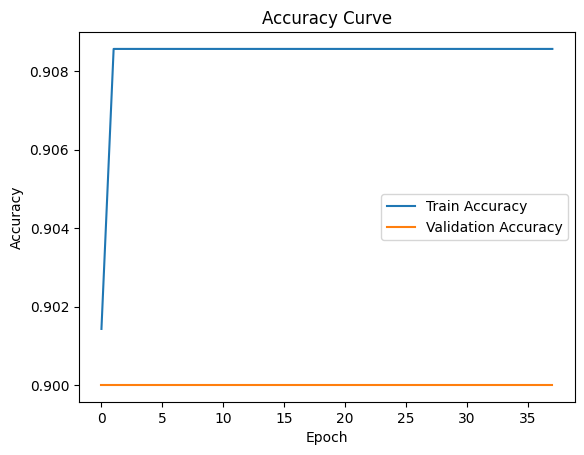

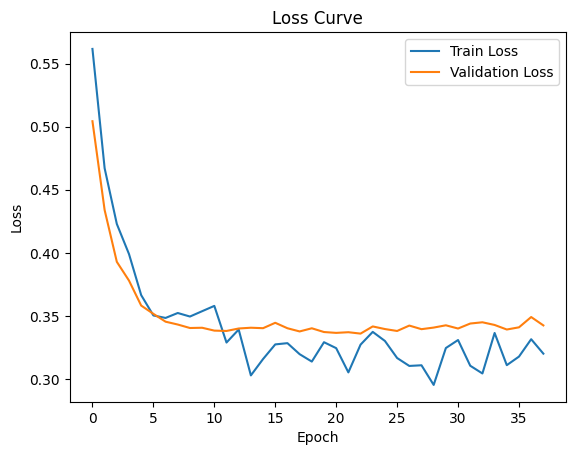

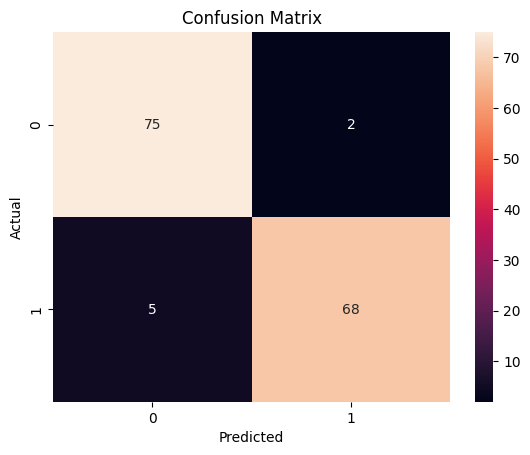

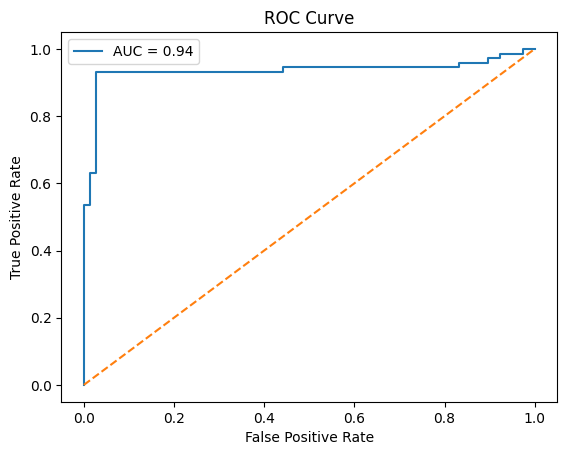

In [63]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results_CkD"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

Epoch 10, Train Loss: 0.2695, Val Loss: 0.3731
Early stopping at epoch: 17

Threshold Tuning:
Threshold 0.30: Accuracy 0.8733
Threshold 0.35: Accuracy 0.8800
Threshold 0.40: Accuracy 0.8867
Threshold 0.45: Accuracy 0.8800
Threshold 0.50: Accuracy 0.8667
Threshold 0.55: Accuracy 0.8733
Threshold 0.60: Accuracy 0.8800
Threshold 0.65: Accuracy 0.8867
Threshold 0.70: Accuracy 0.9000
Threshold 0.75: Accuracy 0.8867

Best Threshold: 0.70

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[73  4]
 [11 62]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91        77
         1.0       0.94      0.85      0.89        73

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


ROC-AUC Score:
0.9391567336772816
True Positive Rate (TPR):  0.8493
False Positive Rate (FPR): 0.0519
Precision: 0.9394
Recall:    0.8493
F1-Sco

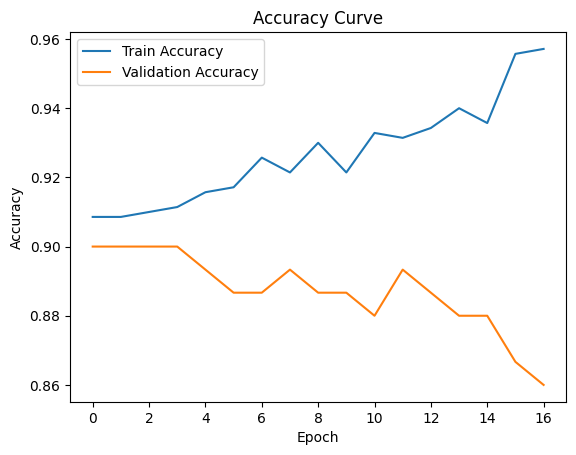

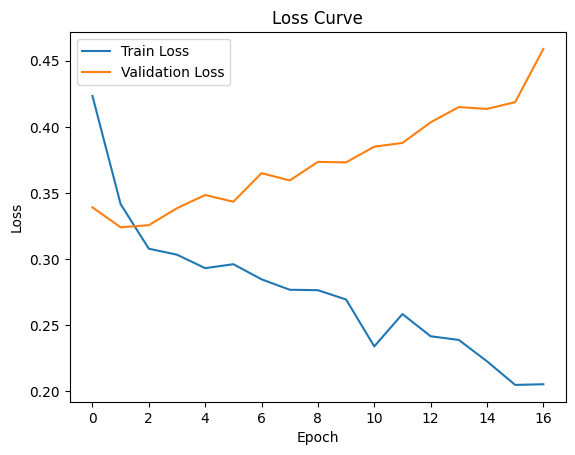

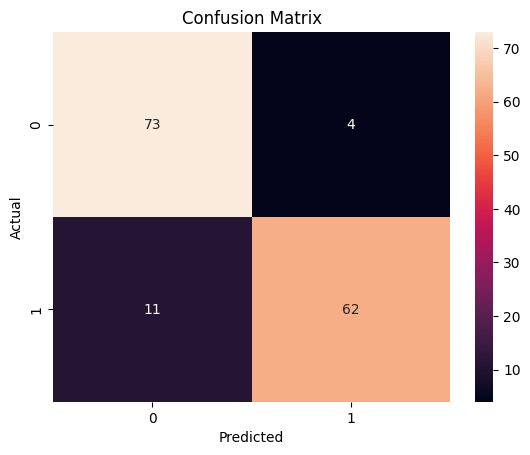

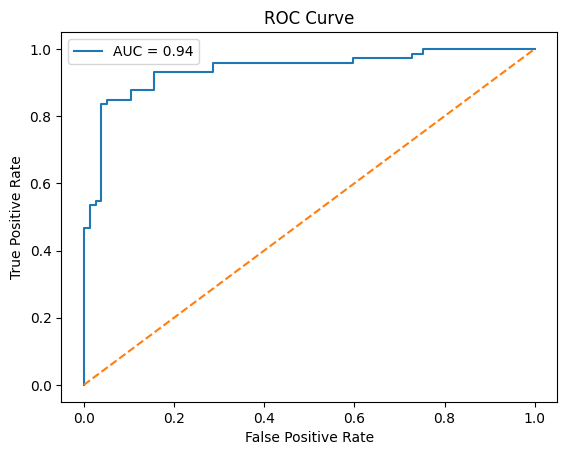

In [64]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0_CKD"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

In [57]:

# =========================
# 5. Training Function
# =========================
def train_model(X_train_np, y_train_np, X_val_np, y_val_np,
                input_size, epochs=100, patience=15,
                batch_size=16, lr=0.001):
    """Train HGRDIN and return best model + history."""
 
    # Scale
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train_np)
    X_vl    = scaler.transform(X_val_np)
 
    # Tensors
    Xtr = torch.tensor(X_tr, dtype=torch.float32)
    Xvl = torch.tensor(X_vl, dtype=torch.float32)
    ytr = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
    yvl = torch.tensor(y_val_np,   dtype=torch.float32).view(-1, 1)
 
    loader = DataLoader(TensorDataset(Xtr, ytr),
                        batch_size=batch_size, shuffle=True)
 
    model     = HGRDIN(input_size)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
 
    best_val_loss = float('inf')
    best_state    = model.state_dict()
    counter       = 0
 
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []
 
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            out  = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_loss = epoch_loss / len(loader)
 
        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_out  = model(Xvl)
            val_loss = criterion(val_out, yvl).item()
 
            tr_probs = torch.sigmoid(model(Xtr))
            tr_preds = (tr_probs > 0.5).float()
            vl_probs = torch.sigmoid(val_out)
            vl_preds = (vl_probs > 0.5).float()
 
            tr_acc = accuracy_score(ytr.numpy(), tr_preds.numpy())
            vl_acc = accuracy_score(yvl.numpy(), vl_preds.numpy())
 
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(tr_acc)
        val_acc_hist.append(vl_acc)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            counter       = 0
        else:
            counter += 1
        if counter >= patience:
            print(f"    Early stopping at epoch {epoch + 1}")
            break
 
    model.load_state_dict(best_state)
    return model, scaler, {
        "train_loss": train_loss_hist,
        "val_loss":   val_loss_hist,
        "train_acc":  train_acc_hist,
        "val_acc":    val_acc_hist,
    }
 
 
# =========================
# 6. Evaluation Function
# =========================
def evaluate_model(model, scaler, X_test_np, y_test_np):
    """Return full metrics dict for a test set."""
    X_sc = scaler.transform(X_test_np)
    Xts  = torch.tensor(X_sc, dtype=torch.float32)
    yts  = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)
 
    model.eval()
    with torch.no_grad():
        logits = model(Xts)
        probs  = torch.sigmoid(logits)
 
    # Threshold tuning on the test set
    best_acc, best_thresh = 0, 0.5
    for t in np.arange(0.3, 0.8, 0.05):
        preds = (probs > t).float()
        acc   = accuracy_score(yts.numpy(), preds.numpy())
        if acc > best_acc:
            best_acc, best_thresh = acc, t
 
    preds = (probs > best_thresh).float()
    cm    = confusion_matrix(yts.numpy(), preds.numpy())
    tn, fp, fn, tp = cm.ravel()
 
    return {
        "accuracy":  accuracy_score(yts.numpy(), preds.numpy()),
        "precision": precision_score(yts.numpy(), preds.numpy(), zero_division=0),
        "recall":    recall_score(yts.numpy(), preds.numpy(), zero_division=0),
        "f1":        f1_score(yts.numpy(), preds.numpy(), zero_division=0),
        "roc_auc":   roc_auc_score(yts.numpy(), probs.numpy()),
        "tpr":       tp / (tp + fn) if (tp + fn) > 0 else 0,
        "fpr":       fp / (fp + tn) if (fp + tn) > 0 else 0,
        "threshold": best_thresh,
        "cm":        cm,
        "probs":     probs.numpy(),
        "y_true":    yts.numpy(),
    }
 
 
# =========================
# 7. Run All Splits
# =========================
SPLITS = [
    (0.70, 0.30),   # 70 / 30
    (0.60, 0.40),   # 60 / 40
    (0.80, 0.20),   # 80 / 20
    (0.50, 0.50),   # 50 / 50
    (0.65, 0.35),   # 65 / 35
]
 
all_results  = {}   # metrics per split
all_history  = {}   # loss/acc curves per split
 
for train_ratio, test_ratio in SPLITS:
    label = f"{int(train_ratio*100)}/{int(test_ratio*100)}"
    print(f"\n{'='*50}")
    print(f"  Split: {label}")
    print(f"{'='*50}")
 
    # ---- Split ----
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )
    # Use 15 % of train as validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42
    )
 
    print(f"  Train: {len(X_tr):4d}  Val: {len(X_val):4d}  Test: {len(X_test):4d}")
 
    # ---- Train ----
    model, scaler, history = train_model(
        X_tr, y_tr, X_val, y_val,
        input_size=X.shape[1]
    )
 
    # ---- Evaluate ----
    metrics = evaluate_model(model, scaler, X_test, y_test)
    all_results[label] = metrics
    all_history[label] = history
 
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")
    print(f"  F1-Score : {metrics['f1']:.4f}")
    print(f"  ROC-AUC  : {metrics['roc_auc']:.4f}")
    print(f"  Threshold: {metrics['threshold']:.2f}")
 
 
# =========================
# 8. Summary Table
# =========================
summary_rows = []
for label, m in all_results.items():
    summary_rows.append({
        "Split":     label,
        "Accuracy":  round(m["accuracy"],  4),
        "Precision": round(m["precision"], 4),
        "Recall":    round(m["recall"],    4),
        "F1-Score":  round(m["f1"],        4),
        "ROC-AUC":   round(m["roc_auc"],   4),
        "TPR":       round(m["tpr"],       4),
        "FPR":       round(m["fpr"],       4),
        "Threshold": round(m["threshold"], 2),
    })
 


  Split: 70/30
  Train:  595  Val:  105  Test:  300
    Early stopping at epoch 22
  Accuracy : 0.9267
  Precision: 0.9225
  Recall   : 0.9225
  F1-Score : 0.9225
  ROC-AUC  : 0.9253
  Threshold: 0.45

  Split: 60/40
  Train:  510  Val:   90  Test:  400
    Early stopping at epoch 17
  Accuracy : 0.9350
  Precision: 0.9326
  Recall   : 0.9326
  F1-Score : 0.9326
  ROC-AUC  : 0.9313
  Threshold: 0.40

  Split: 80/20
  Train:  680  Val:  120  Test:  200
    Early stopping at epoch 22
  Accuracy : 0.9300
  Precision: 0.9400
  Recall   : 0.9216
  F1-Score : 0.9307
  ROC-AUC  : 0.9417
  Threshold: 0.55

  Split: 50/50
  Train:  425  Val:   75  Test:  500
    Early stopping at epoch 17
  Accuracy : 0.9280
  Precision: 0.9298
  Recall   : 0.9221
  F1-Score : 0.9259
  ROC-AUC  : 0.9312
  Threshold: 0.40

  Split: 65/35
  Train:  552  Val:   98  Test:  350
    Early stopping at epoch 19
  Accuracy : 0.9343
  Precision: 0.9341
  Recall   : 0.9286
  F1-Score : 0.9313
  ROC-AUC  : 0.9230
  Thresh

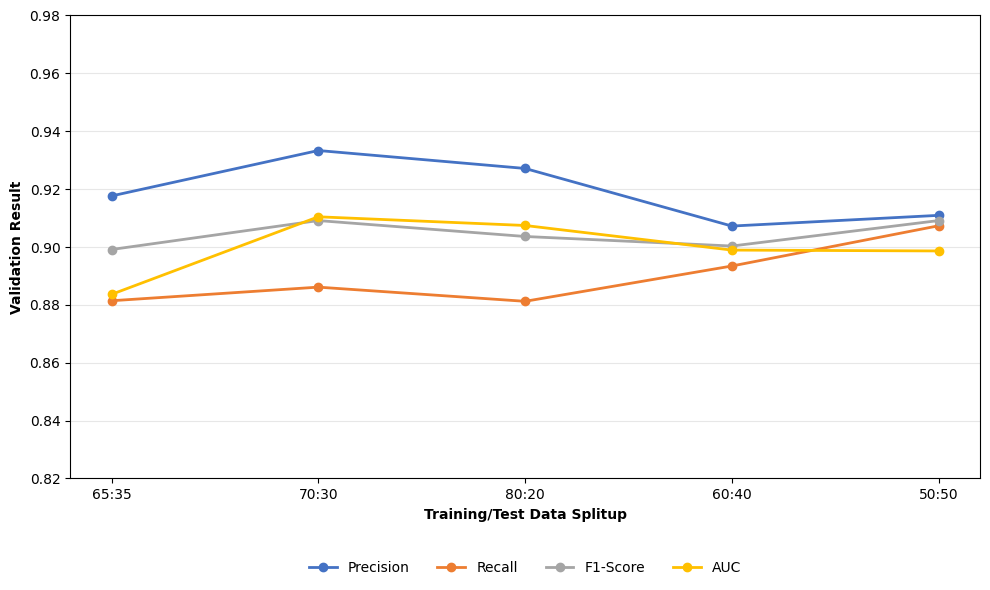

In [58]:
import matplotlib.pyplot as plt

# 1. Define the Data Labels (Ordered as per your image)
splits = ['65:35', '70:30', '80:20', '60:40', '50:50']

# Updated metrics from your latest data
precision = [0.9176, 0.9333, 0.9271, 0.9072, 0.9109]
recall    = [0.8814, 0.8861, 0.8812, 0.8934, 0.9073]
f1_score  = [0.8991, 0.9091, 0.9036, 0.9003, 0.9091]
auc       = [0.8836, 0.9104, 0.9074, 0.8989, 0.8986]

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Plotting each line with markers
plt.plot(splits, precision, marker='o', label='Precision', color='#4472c4', linewidth=2)
plt.plot(splits, recall,    marker='o', label='Recall',    color='#ed7d31', linewidth=2)
plt.plot(splits, f1_score,  marker='o', label='F1-Score',  color='#a5a5a5', linewidth=2)
plt.plot(splits, auc,       marker='o', label='AUC',       color='#ffc000', linewidth=2)

# 4. Formatting (Matching your style)
plt.xlabel('Training/Test Data Splitup', fontweight='bold')
plt.ylabel('Validation Result', fontweight='bold')
plt.ylim(0.82, 0.98)  # Setting the Y-axis range to match your image
plt.grid(axis='y', linestyle='-', alpha=0.3)

# Place legend at the bottom
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.savefig(os.path.join(results_dir, "spliting.png"), dpi=300)

plt.tight_layout()
plt.show()

In [60]:
import numpy as np
import pandas as pd
import time  # Added for timing
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN (With Timing)
    # =========================
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    train_duration = end_train - start_train

    # =========================
    # PREDICT (With Timing)
    # =========================
    start_test = time.perf_counter()
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    end_test = time.perf_counter()
    test_duration = end_test - start_test

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr_list, tpr_list, _ = roc_curve(y_test, y_pred_prob)

    # Store results including time
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "Train Time": round(train_duration, 4),
        "Test Time": round(test_duration, 4),
        "fpr": fpr_list,
        "tpr": tpr_list
    }

    tn, fp, fn, tp = cm.ravel()
    tpr_val = tp / (tp + fn)
    fpr_val = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr_val:.4f}")
    print(f"False Positive Rate (FPR): {fpr_val:.4f}")

    # Print Time Results
    print(f"Training Time : {train_duration:.4f} sec")
    print(f"Testing Time  : {test_duration:.4f} sec")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name

# =========================
# AFTER LOOP: Summary Table
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)

# Optional: Display time comparison table
time_df = pd.DataFrame.from_dict(results, orient='index')[['Train Time', 'Test Time', 'AUC']]
print("\nModel Time Comparison:")
print(time_df)


──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  1.0000
False Positive Rate (FPR): 1.0000
Training Time : 0.1188 sec
Testing Time  : 0.0040 sec

Accuracy  : 0.4800
Precision : 0.4800
Recall    : 1.0000
F1-Score  : 0.6486
ROC-AUC   : 0.8734

Confusion Matrix:
[[  0 182]
 [  0 168]]


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.48      1.00      0.65       168

    accuracy                           0.48       350
   macro avg       0.24      0.50      0.32       350
weighted avg       0.23      0.48      0.31       350


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.3393
False Positive Rate (FPR): 0.0330
Training Time : 0.0250 sec
Testing Time  : 0.0029 sec

Accuracy  : 0.6657
Precision : 0.9048
Recall    : 0.3393
F1-Score  : 0.4935
ROC-AUC   : 0.6532

Confusion Matrix:
[[176   6]
 [111  57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.97      0.75       182
           1       0.90      0.34      0.49       168

    accuracy                           0.67       350
   macro avg       0.76      0.65 

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[

True Positive Rate (TPR):  1.0000
False Positive Rate (FPR): 1.0000
Training Time : 0.1265 sec
Testing Time  : 0.0329 sec

Accuracy  : 0.4800
Precision : 0.4800
Recall    : 1.0000
F1-Score  : 0.6486
ROC-AUC   : 0.5000

Confusion Matrix:
[[  0 182]
 [  0 168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.48      1.00      0.65       168

    accuracy                           0.48       350
   macro avg       0.24      0.50      0.32       350
weighted avg       0.23      0.48      0.31       350


──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

True Positive Rate (TPR):  0.6488
False Positive Rate (FPR): 0.2418
Training Time : 0.5447 sec
Testing Time  : 0.0277 sec

Accuracy  : 0.7057
Precision : 0.7124
Recall    : 0.6488
F1-Score  : 0.6791
ROC-AUC   : 0.7742

Confusion Matrix:
[[138  44]
 [ 59 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.76      0.73       182
           1       0.71      0.65      0.68       168

    accuracy                           0.71       350
   macro avg       0.71      0.70      0.70       350
weighted avg       0.71      0.71      0.70       350


──────────────────────────────────────────────────
Model: KNN
──────────────────────────────────────────────────
True Positive Rate (TPR):  1.0000
False Positive Rate (FPR): 1.0000
Training Time : 0.0035 sec
Testing Time  : 0.0331 sec

Accuracy  : 0.4800
Precision : 0.4800
Recall    : 1.0000
F1-Score  : 0.6486
ROC-AUC   : 0.5000

Confusion Matrix:
[[  0 182]
 [  0 168]]

Classification

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0

True Positive Rate (TPR):  0.2679
False Positive Rate (FPR): 0.1813
Training Time : 0.2194 sec
Testing Time  : 0.0087 sec

Accuracy  : 0.5543
Precision : 0.5769
Recall    : 0.2679
F1-Score  : 0.3659
ROC-AUC   : 0.6902

Confusion Matrix:
[[149  33]
 [123  45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.82      0.66       182
           1       0.58      0.27      0.37       168

    accuracy                           0.55       350
   macro avg       0.56      0.54      0.51       350
weighted avg       0.56      0.55      0.52       350


🏆 BEST MODEL: Logistic Regression
AUC Score   : 0.8734

Model Time Comparison:
                     Train Time  Test Time     AUC
Logistic Regression      0.1188     0.0040  0.8734
dt                       0.0250     0.0029  0.6532
gnb                      0.0179     0.0141  0.5000
SVM                      0.1265     0.0329  0.5000
Random Forest            0.5447     0.0277  0.7742
KNN

                         time
Logistic Regression      0.1188     
dt                       0.0250     
gnb                      0.0179     
SVM                      0.1265     
Random Forest            0.5447     
KNN                      0.0035     
XGBoost                  0.2194     